# Data download
Download the raw data `02_dex_annotated_cd8.h5ad` and the experimentally validated table `media-1.xlsx` and save to `../../data/Kocher_SARS-CoV-2/`:

https://zenodo.org/records/15691612

https://www.biorxiv.org/content/biorxiv/early/2024/10/31/2024.10.30.620795/DC1/embed/media-1.xlsx?download=true

In [1]:
import os
# Change cwd to the notebook's directory for VS Code
try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("Could not find notebook path. Running from:", os.getcwd())


Changed directory to: /lustre/groups/imm01/workspace/yang/DextraDemixer/experiments/Kocher_SARS-CoV-2


In [2]:
import sys
sys.path.append("../../")

import pandas as pd
import numpy as np
import seaborn as sns
from dextrademixer.model import DextraDemixer
import muon as mu
import scirpy as ir
import scanpy as sc
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mudata")

%load_ext autoreload
%autoreload 2

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


# Data Preprocessing

In [3]:
adata = mu.read("../../data/Kocher_SARS-CoV-2/02_dex_annotated_cd8.h5ad")
adata

AnnData object with n_obs × n_vars = 53907 × 18471
    obs: 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'LTDEMIAQY', 'YTN

In [4]:
ir.io.upgrade_schema(adata)

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


In [5]:
# Convert adata to mdata
gex_obs = ['experiment', 'donor', 'sample']
airr_obs = ['binding_10x', 'binding_ct', 'clone_id',  'clone_id_size', 
            'clone_size', 'clonotype_sequence']
airr_uns = ["clonotype_sequence_dict", "ir_dist_aa_identity"]

adata_gex = sc.AnnData(adata.X, obs=adata.obs[gex_obs], var=adata.var, )
adata_dex = sc.AnnData(adata.obs[adata.uns["epitopes"]])
for g in gex_obs:
    adata_dex.obs[g] = adata.obs[g]
adata_dex.var['gene_ids'] = adata.uns["epitopes"]
adata_ir = sc.AnnData()
for a in airr_obs:
    adata_ir.obs[a] = adata.obs[a]

for a in airr_uns:
    adata_ir.uns[a] = adata.uns[a]
adata_ir.obsm["airr"] = adata.obsm['airr']

mdata = mu.MuData({"gex":adata_gex, "dex":adata_dex, "airr":adata_ir})
mdata

MuData object with n_obs × n_vars = 53907 × 18492
  3 modalities
    gex:	53907 x 18471
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids', 'feature_types-0', 'genome-0', 'n_cells-0', 'feature_types-1', 'genome-1', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    dex:	53907 x 21
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    airr:	53907 x 0
      obs:	'binding_10x', 'binding_ct', 'clone_id', 'clone_id_size', 'clone_size', 'clonotype_sequence'
      uns:	'clonotype_sequence_dict', 'ir_dist_aa_identity'
      obsm:	'airr'

In [6]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [7]:
# Separate to experiment and epitope specific mdata

for epitope in ["LTDEMIAQY", "YLQPRTFLL"]:
    for experiment in ["first_experiment", "second_experiment", "third_experiment"]:
        if os.path.exists(f"preprocessed/mdat_{epitope[:3]}_{experiment}.h5mu"):
            print(f"File for epitope {epitope} and experiment {experiment} already exists. Skipping...")
            continue
        mdat_epi = mdata.copy()
        mu.pp.filter_obs(mdat_epi, "dex:experiment", lambda x: np.isin(x, [experiment]))
        mdat_epi = mdat_epi[~np.isnan(mdat_epi.mod['dex'][:, epitope].X.toarray())].copy()
        mdat_epi['gex'].var['gene_ids'] = 'nan'
        os.makedirs('preprocessed', exist_ok=True)
        mdat_epi.write(f"preprocessed/mdat_{epitope[:3]}_{experiment}.h5mu")

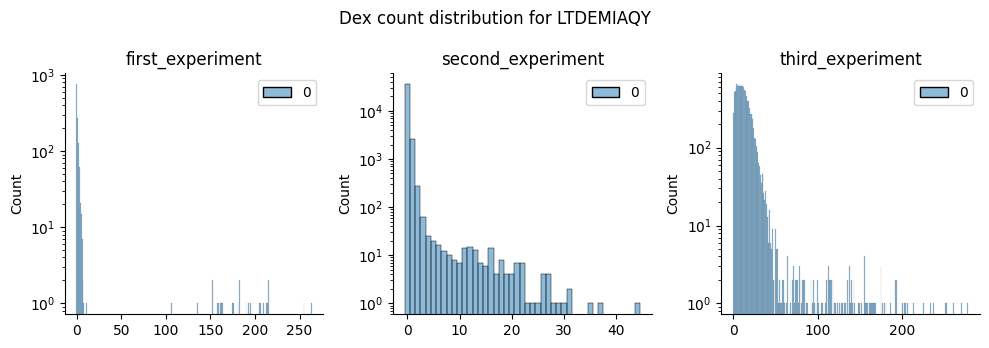

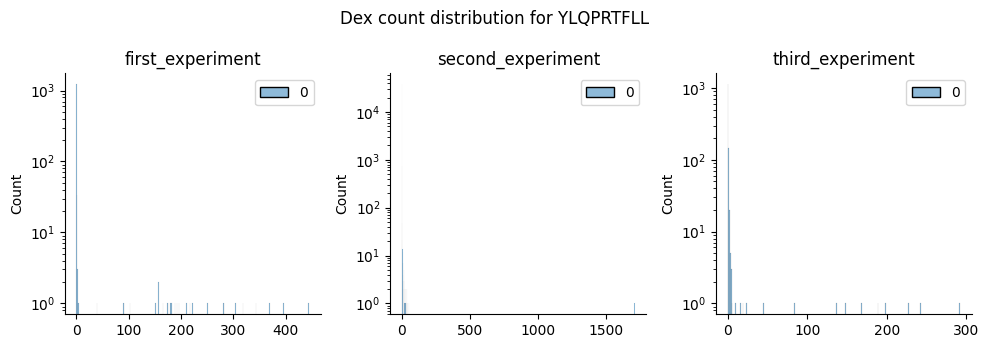

In [8]:
# Visualize UMI counts

for epitope in ['LTDEMIAQY', 'YLQPRTFLL']:
    plt.figure(figsize=(10, 3.5))
    for experiment in ['first_experiment', 'second_experiment', 'third_experiment']:
        plt.subplot(1, 3, ['first_experiment', 'second_experiment', 'third_experiment'].index(experiment)+1)
        mdat_LTD = mu.read(f"preprocessed/mdat_{epitope[:3]}_{experiment}.h5mu")
        sns.histplot(mdat_LTD['dex'][:, epitope].X, discrete=True)
        plt.title(experiment)
        sns.despine()
        plt.yscale('log')
    plt.suptitle(f'Dex count distribution for {epitope}')
    plt.tight_layout()
    plt.show()

# Run DextraDemixer

In [9]:
# Load experimental results
exp_results = pd.read_excel("../../data/Kocher_SARS-CoV-2/media-1.xlsx", header=3, sheet_name='Suppl. Table 6')
exp_results = exp_results[exp_results['Dextramer specificity'] == 'A*01/LTD']
exp_results = exp_results.drop_duplicates('TCR clone ')
exp_results = exp_results[exp_results['Successfull re-expression'] == 'yes'].copy()
exp_results['label'] = exp_results['Validated specificity'] != 'no'

exp_results

,TCR clone,Donor,Dextramer specificity,V-segment,J-segment,CDR3_Nucleotide,CDR3_Amino acid,V-segment.1,J-segment.1,CDR3_Nucleotide.1,CDR3-Amino acid,Successfull re-expression,Validated specificity,label
0,646.0,A4,A*01/LTD,TRAV38-1,TRAJ36,TGTGCTTTCATTCAAACTGGGGCAAACAACCTCTTCTTT,CAFIQTGANNLFF,TRBV9,TRBJ1-1,TGTGCCAGCAGCGTACCGGACCAATTTCGGCTTTTCTTT,CASSVPDQFRLFF,yes,yes,True
1,772.0,A4,A*01/LTD,TRAV29/DV5,TRAJ54,TGTGCAGCAAGCGGAGGAGCCCAGAAGCTGGTATTT,CAASGGAQKLVF,TRBV7-6,TRBJ2-2,TGTGCCAGCAGCTTGAGGGTCACGAACACCGGGGAGCTGTTTTTT,CASSLRVTNTGELFF,yes,yes,True
2,99.0,A4,A*01/LTD,TRAV5,TRAJ24,TGTGCAGAGAGGAGGGGGAAATTGCAGTTT,CAERRGKLQF,TRBV15,TRBJ2-5,TGTGCCACCAGCAGGGGCCCTGGGGGGAGTAAAGCGGGGGAGACCC...,CATSRGPGGSKAGETQYF,yes,yes,True
3,201.0,A4,A*01/LTD,TRAV19,TRAJ4,TGTGCTCTGAGTCTTTCTGGTGGCTACAATAAGCTGATTTTT,CALSLSGGYNKLIF,TRBV6-6,TRBJ2-7,TGTGCCAGCAGTCAGGGGGTGATCGACGAGCAGTACTTC,CASSQGVIDEQYF,yes,yes,True
4,718.0,A4,A*01/LTD,TRAV3,TRAJ45,TGTGCTGTGAGACAGACAGGAGGAGGTGCTGACGGACTCACCTTT,CAVRQTGGGADGLTF,TRBV29-1,TRBJ2-2,TGCAGCGTGCCGGGACTAGTTTACCCCGGGGAGCTGTTTTTT,CSVPGLVYPGELFF,yes,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,2997.0,HIM,A*01/LTD,TRAV9-2,TRAJ9,TGTGCTCTGAGTGCTCTAAATACTGGAGGCTTCAAAACTATCTTT,CALSALNTGGFKTIF,TRBV20-1,TRBJ1-1,TGCAGTGCTAGCGGACTTACCCGGGACAGCCCTTTGAACACTGAAG...,CSASGLTRDSPLNTEAFF,yes,yes,True
86,475.0,HIM,A*01/LTD,TRAV3,TRAJ40,TGTGCTGTGAGCGGTCCTACCTCAGGAACCTACAAATACATCTTT,CAVSGPTSGTYKYIF,TRBV5-5,TRBJ1-5,TGTGCCAGCAGCTTGTGGGACGGGGGGAATCAGCCCCAGCATTTT,CASSLWDGGNQPQHF,yes,yes,True
87,5546.0,HIM,A*01/LTD,TRAV21,TRAJ49,TGTGCTGTGAGGCCCGGTAACCAGTTCTATTTT,CAVRPGNQFYF,TRBV27,TRBJ2-3,TGTGCCAGCAGTTTTCTGTACACAGATACGCAGTATTTT,CASSFLYTDTQYF,yes,yes,True
88,1276.0,HIM,A*01/LTD,TRAV14/DV4,TRAJ52,TGTGCAATGTACTATGGTACTAGCTATGGAAAGCTGACATTT,CAMYYGTSYGKLTF,TRBV19,TRBJ2-4,TGTGCCAGTAGATCGCGGGACCTCGTAGCCAAAAACATTCAGTACTTC,CASRSRDLVAKNIQYF,yes,minimal reactivity,True


In [10]:
for f_in in ['mdat_LTD_first_experiment.h5mu', 'mdat_LTD_second_experiment.h5mu', 
             'mdat_LTD_third_experiment.h5mu',
             'mdat_YLQ_first_experiment.h5mu', 'mdat_YLQ_second_experiment.h5mu', 
             'mdat_YLQ_third_experiment.h5mu']:
    pmhc_key = 'LTDEMIAQY' if 'LTD' in f_in else 'YLQPRTFLL'
    mdata = mu.read(f'preprocessed/{f_in}')

    clone_id = mdata.obs['airr:clone_id'].copy().astype(float)
    max_id = clone_id.max()
    num_nans = clone_id.isna().sum()
    clone_id[clone_id.isna()] = np.arange(max_id, max_id+num_nans)


    df_airr = mdata["airr"].obs.copy()
    df_airr["clone_id"] = df_airr["clone_id"].astype("float")
    original_index = df_airr.index
    df_airr = df_airr.merge(exp_results, how="left", left_on="clone_id", right_on="TCR clone ")
    df_airr.index = original_index
    df_airr['pMHC_count'] = mdata["dex"][:, pmhc_key].X[:, 0]
    y_true = df_airr['label'].fillna('unknown').astype(str)

    mixer = DextraDemixer(model_type='mixturemodelkmeans', mode='I', alpha_model='overdispersion', 
                          model_config={'hyperprior': 1e0, 'alpha_offset': 5,})

    mixer.preprocess_model_data(mdata, pmhc_key=pmhc_key, gex_key='dex', neg_ctrl_key=None, use_size_factor=False, ir_clone_key=None, outlier_threshold=None)
    mixer.fit_svi(svi_config={"maxiter": 1000, "adam": 
                              {"init_value": 3e-1, "end_value": 3e-3, "decay_rate": 0.995, "transition_steps": 1},}, 
                              nof_inits=10, rng_key=42,)

    for clone_median in [True, False]:
        p_pred, assignment = mixer.predict_posterior_class(target_fdr=None, threshold=0.5, clonotype_median_p=clone_median, clone_id=clone_id)
        
        config = (f"clone={clone_median},data={f_in.replace('_experiment.h5mu', '').replace('mdat_','')}")
        df_airr[f"p_pred-{config}"] = p_pred
        df_airr[f"assigment-{config}"] = assignment

    os.makedirs('results/predictions', exist_ok=True)
    df_airr.to_csv(f"results/predictions/results_{f_in.replace('_experiment.h5mu', '').replace('mdat_','')}.csv")


100%|██████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 94.19it/s, avg. loss [991-1000]: 811.9923]
